# Accuracy × Difficulty Level Analysis  (v2)
### Digit Span Backwards — STIM ON vs OFF × Difficulty (2 / 3 / 4 digits)

**Structure:**
- Session 2  (14 trials) → digit counts 2, 3, 4
- Session 3  (14 trials) → digit counts 2, 3, 4
- Combined   (28 trials) → digit counts 2, 3, 4

For each digit count × session:
- STIM ON accuracy vs STIM OFF accuracy
- **p-value** (Fisher's Exact — appropriate for binary accuracy with small N)
- **Cohen's d** (pooled, treating each trial as a binary 0/1 observation)

**Behavioral stats only — no neural metrics.**

## Cell 1 — Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.2,
    'figure.dpi':        150,
    'savefig.dpi':       180,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

C_ON  = '#1A56DB'   # STIM ON  → blue
C_OFF = '#90A4AE'   # STIM OFF → grey

DIFF_META = {
    2: dict(label='Easy',   emoji='🟢', color='#43A047'),
    3: dict(label='Medium', emoji='🟡', color='#F9A825'),
    4: dict(label='Hard',   emoji='🔴', color='#E53935'),
    5: dict(label='God',    emoji='⚡', color='#6A1B9A'),
}

print('Imports OK')

Imports OK


## Cell 2 — File Paths  ← EDIT THESE

In [2]:
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESHOLD = 2.0
DIGIT_LEVELS   = [2, 3, 4]   # digit counts to analyse

print('Paths set.')

Paths set.


## Cell 3 — Data Loading + Alignment Pipeline
*(unchanged from v1)*

In [3]:
def load_session(json_path, csv_path, events_path, stim_threshold=2.0):
    with open(json_path) as f:
        report = json.load(f)
    df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    subject = str(df['Subject'].iloc[0])
    session = str(df['Session'].iloc[0])
    date    = str(df['SessionDate'].iloc[0])

    # Alignment anchor
    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_start_tick: break
    assert stim_start_tick, 'No 0→>0 mA transition found!'

    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(ms):       return float(ms) + MANUAL_OFFSET - stim_start_tick
    def tick_to_rel(arr): return np.asarray(arr, dtype=float) - stim_start_tick

    # mA trace
    bslf_tick, bslf_mA = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            bslf_tick.append(pkt['TicksInMs'])
            bslf_mA.append(pkt['Left']['mA'])
    bslf_rel = tick_to_rel(np.array(bslf_tick, dtype=float))
    bslf_mA  = np.array(bslf_mA, dtype=float)

    # Digit sequences
    digit_rows = df['Digit'].tolist()
    trial_digit_seqs, offset = {}, 0
    for tn in range(1, 15):
        row = ev[(ev['Event_Type']=='Main Trial Start') & (ev['Trial_Number']==tn)]
        if row.empty: continue
        n = int(row.iloc[0]['Num_Digits'])
        trial_digit_seqs[tn] = digit_rows[offset:offset+n]
        offset += n

    def ev_times_all(etype, tn):
        rows = ev[(ev['Event_Type']==etype) & (ev['Trial_Number']==tn)]
        return [float(x) for x in rows['Time_ms'].tolist()]
    def ev_first(etype, tn):
        v = ev_times_all(etype, tn); return v[0] if v else None

    trials = []
    for tn in range(1, 15):
        sr = ev[(ev['Event_Type']=='Main Trial Start') & (ev['Trial_Number']==tn)]
        if sr.empty: continue
        r = sr.iloc[0]
        t = dict(
            num=tn,
            digits=int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None,
            acc=int(r['ACC'])           if pd.notna(r['ACC'])        else None,
            cresp=str(int(r['CRESP']))  if pd.notna(r['CRESP'])      else '?',
            resp=str(int(r['RESP']))    if pd.notna(r['RESP'])        else '?',
            digit_seq=trial_digit_seqs.get(tn, []),
        )
        for key, etype in [('start','Main Trial Start'),('end','Main Trial End'),
                            ('cs','Choice Start'),('ce','Choice End'),
                            ('fb_s','Feedback Start'),('fb_e','Feedback End')]:
            ms = ev_first(etype, tn)
            t[key] = to_rel(ms) if ms is not None else None
        trials.append(t)

    meta = dict(subject=subject, session=session, date=date)
    print(f'Loaded: Subject={subject}  Session={session}  Date={date}  Trials={len(trials)}')
    return trials, bslf_rel, bslf_mA, meta


def classify_trials(trials, bslf_rel, bslf_mA, threshold=2.0):
    """Tag each trial: stim_on = True if ≥50% of trial window has mA ≥ threshold."""
    for t in trials:
        t0, t1 = t['start'], t['end']
        if t0 is None or t1 is None or t1 <= t0:
            t.update(stim_on=False, stim_frac=0.0); continue
        mask = (bslf_rel >= t0) & (bslf_rel <= t1)
        t_r, t_m = bslf_rel[mask], bslf_mA[mask]
        if len(t_r) < 2:
            t.update(stim_on=False, stim_frac=0.0); continue
        dt        = np.diff(t_r)
        mid_mA    = (t_m[:-1] + t_m[1:]) / 2.0
        total     = t_r[-1] - t_r[0]
        stim_frac = np.sum(dt[mid_mA >= threshold]) / total if total > 0 else 0.0
        t.update(stim_on=stim_frac >= 0.5, stim_frac=float(stim_frac))
    return trials


print('Pipeline functions defined.')

Pipeline functions defined.


## Cell 4 — Statistics Functions

### How we compute p-value and Cohen's d

**p-value — Fisher's Exact Test**  
Each trial is binary: correct (1) or incorrect (0).  
With small N per cell (typically 3–7 trials) a chi-squared test is invalid (expected cell count < 5).  
Fisher's Exact enumerates all possible 2×2 contingency tables with the same marginals and gives the exact probability — no approximation needed.

```
              Correct   Incorrect
STIM ON   [   a           b    ]   (n_on  trials)
STIM OFF  [   c           d    ]   (n_off trials)
```

**Cohen's d — pooled, treating each trial as 0 or 1**  
Each trial is one observation: accuracy score ∈ {0, 1}.  
Pooled SD is computed with ddof=1 per group (Bessel's correction).

```
pooled_sd = sqrt( [(n_on-1)*sd_on² + (n_off-1)*sd_off²] / (n_on + n_off - 2) )
d         = (mean_on - mean_off) / pooled_sd
```

Interpretation: |d| < 0.2 negligible, 0.2–0.5 small, 0.5–0.8 medium, ≥ 0.8 large.

In [15]:
def fisher_exact_p(n_corr_a, n_a, n_corr_b, n_b):
    """Fisher's Exact p-value: group A (ON) vs group B (OFF)."""
    if n_a == 0 or n_b == 0:
        return np.nan
    table = [[n_corr_a,     n_a - n_corr_a],
             [n_corr_b,     n_b - n_corr_b]]
    _, p = stats.fisher_exact(table)
    return float(p)


def cohens_d_binary(scores_a, scores_b):
    """
    Pooled Cohen's d on binary (0/1) accuracy arrays.
    Requires at least 2 observations in each group for SD.
    Returns NaN when SD is 0 (all same outcome) or N too small.
    """
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    var_a = np.var(a, ddof=1)
    var_b = np.var(b, ddof=1)
    pooled_var = ((len(a) - 1) * var_a + (len(b) - 1) * var_b) / (len(a) + len(b) - 2)
    pooled_sd  = np.sqrt(pooled_var)
    if pooled_sd == 0:
        return np.nan
    return float((np.mean(a) - np.mean(b)) / pooled_sd)


def d_label(d):
    """Text interpretation of |d|."""
    if np.isnan(d): return 'N/A'
    v = abs(d)
    if v >= 0.8:  return 'large'
    if v >= 0.5:  return 'medium'
    if v >= 0.2:  return 'small'
    return 'negligible'


def sig_stars(p):
    if np.isnan(p): return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'ns'


def compute_cell(df_sub):
    """
    Given a subset DataFrame for one (session × digit_count),
    return dict with all stats for STIM ON vs STIM OFF.
    """
    on  = df_sub[df_sub['stim_on'] == True]['acc'].dropna().values
    off = df_sub[df_sub['stim_on'] == False]['acc'].dropna().values

    n_on = len(on)
    n_corr_on = int(on.sum()) if n_on > 0 else 0

    n_off = len(off)
    n_corr_off = int(off.sum()) if n_off > 0 else 0

    acc_on  = on.mean()  if n_on  > 0 else np.nan
    acc_off = off.mean() if n_off > 0 else np.nan

    p = fisher_exact_p(n_corr_on, n_on, n_corr_off, n_off)
    d = cohens_d_binary(on, off)

    return dict(
        on=on, off=off,
        n_on=n_on,   n_corr_on=n_corr_on,   acc_on=acc_on,
        n_off=n_off, n_corr_off=n_corr_off, acc_off=acc_off,
        p=p, d=d,
    )


print('Stats functions defined.')

Stats functions defined.


## Cell 5 — Build DataFrames

In [16]:
def build_df(sessions):
    rows = []
    for label, trials in sessions:
        for t in trials:
            d = t.get('digits', None)
            if d is None: continue
            dm = DIFF_META.get(d, dict(label=f'{d}-digit', emoji='', color='#555'))
            rows.append(dict(
                session    = label,
                trial_num  = t['num'],
                digits     = d,
                diff_label = dm['label'],
                diff_color = dm['color'],
                acc        = t['acc'],
                stim_on    = t.get('stim_on', False),
                stim_frac  = t.get('stim_frac', 0.0),
            ))
    return pd.DataFrame(rows)


print('build_df defined.')

build_df defined.


## Cell 6 — Load + Classify Sessions

In [17]:
trials_s2, bslf_rel_s2, bslf_mA_s2, meta_s2 = load_session(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2, STIM_THRESHOLD)

trials_s3, bslf_rel_s3, bslf_mA_s3, meta_s3 = load_session(
    JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3, STIM_THRESHOLD)

classify_trials(trials_s2, bslf_rel_s2, bslf_mA_s2, STIM_THRESHOLD)
classify_trials(trials_s3, bslf_rel_s3, bslf_mA_s3, STIM_THRESHOLD)

df_s2  = build_df([('Session 2', trials_s2)])
df_s3  = build_df([('Session 3', trials_s3)])
df_all = build_df([('Session 2', trials_s2), ('Session 3', trials_s3)])

print('\nSession 2 trial breakdown:')
print(df_s2[['trial_num','digits','diff_label','acc','stim_on','stim_frac']].to_string(index=False))
print('\nSession 3 trial breakdown:')
print(df_s3[['trial_num','digits','diff_label','acc','stim_on','stim_frac']].to_string(index=False))

Loaded: Subject=6  Session=2  Date=03-05-2026  Trials=14
Loaded: Subject=6  Session=3  Date=03-05-2026  Trials=14

Session 2 trial breakdown:
 trial_num  digits diff_label  acc  stim_on  stim_frac
         1       2       Easy    1    False   0.000000
         2       2       Easy    1    False   0.000000
         3       3     Medium    1    False   0.263158
         4       3     Medium    1    False   0.000000
         5       4       Hard    1    False   0.000000
         6       4       Hard    0    False   0.000000
         7       4       Hard    0     True   0.960000
         8       4       Hard    0     True   1.000000
         9       4       Hard    1     True   1.000000
        10       4       Hard    0     True   1.000000
        11       4       Hard    0     True   1.000000
        12       4       Hard    0     True   1.000000
        13       4       Hard    0     True   1.000000
        14       4       Hard    0     True   1.000000

Session 3 trial breakdown:
 tria

## Cell 7 — Print Stats Tables
For each session and digit count: STIM ON vs OFF accuracy, p-value, Cohen's d.

In [18]:
for sess_label, df in [('Session 2', df_s2), ('Session 3', df_s3), ('Combined (S2+S3)', df_all)]:
    print(f'\n{"="*72}')
    print(f'  {sess_label}  —  STIM ON vs OFF accuracy by digit count')
    print(f'  p = Fisher\'s Exact   d = pooled Cohen\'s d on binary acc scores')
    print(f'{"="*72}')
    print(f'  {"Digits":<8} {"Stim":<8} {"N":<5} {"Corr":<6} {"Acc%":<8}  '
          f'{"p-value":<10} {"Stars":<6} {"d":<8} {"Effect"}')
    print(f'  {"-"*70}')

    dig_levels = [d for d in DIGIT_LEVELS if d in df['digits'].unique()]
    for d in dig_levels:
        dm  = DIFF_META.get(d, {})
        sub = df[df['digits'] == d]
        c   = compute_cell(sub)

        lbl = f"{dm.get('emoji','')} {dm.get('label',f'{d}-dig')} ({d}d)"
        p_s = f'{c["p"]:.4f}' if not np.isnan(c['p']) else 'N/A   '
        d_s = f'{c["d"]:+.3f}' if not np.isnan(c['d']) else 'N/A'
        for k,v in c.items():
            print(k, type(v), v)

        print(f'  {lbl:<18}  ON   {c["n_on"]:<5} {c["n_corr_on"]:<6} '
              f'{c["acc_on"]*100 if not np.isnan(c["acc_on"]) else 0:.1f}%')
        print(f'  {"":<18}  OFF  {c["n_off"]:<5} {c["n_corr_off"]:<6} '
              f'{c["acc_off"]*100 if not np.isnan(c["acc_off"]) else 0:.1f}%   '
              f'p={p_s}  {sig_stars(c["p"]):<4}  d={d_s}  ({d_label(c["d"])})')
        print(f'  {"-"*70}')


  Session 2  —  STIM ON vs OFF accuracy by digit count
  p = Fisher's Exact   d = pooled Cohen's d on binary acc scores
  Digits   Stim     N     Corr   Acc%      p-value    Stars  d        Effect
  ----------------------------------------------------------------------
on <class 'numpy.ndarray'> []
off <class 'numpy.ndarray'> [1 1]
n_on <class 'int'> 0
n_corr_on <class 'int'> 0
acc_on <class 'float'> nan
n_off <class 'int'> 2
n_corr_off <class 'int'> 2
acc_off <class 'numpy.float64'> 1.0
p <class 'float'> nan
d <class 'float'> nan
  🟢 Easy (2d)         ON   0     0      0.0%
                      OFF  2     2      100.0%   p=N/A           d=N/A  (N/A)
  ----------------------------------------------------------------------
on <class 'numpy.ndarray'> []
off <class 'numpy.ndarray'> [1 1]
n_on <class 'int'> 0
n_corr_on <class 'int'> 0
acc_on <class 'float'> nan
n_off <class 'int'> 2
n_corr_off <class 'int'> 2
acc_off <class 'numpy.float64'> 1.0
p <class 'float'> nan
d <class 'float'> nan

## Cell 8 — Main Plot: STIM ON vs OFF per Digit Count, per Session

Each figure = one analysis scope (Session 2 / Session 3 / Combined).  
Each subplot = one digit count.  
Two bars: STIM ON (blue) vs STIM OFF (grey).  
Bracket shows **p-value** and **Cohen's d**.

In [24]:
def plot_difficulty_stim(df, sess_label, save_path=None, digit_levels=None):
    """
    One figure per session scope.
    Subplots: one per digit count.
    Each subplot: STIM ON vs STIM OFF bar + p-value + Cohen's d bracket.
    Individual trial dots shown as scatter.
    """
    if digit_levels is None:
        digit_levels = [d for d in DIGIT_LEVELS if d in df['digits'].unique()]

    n = len(digit_levels)
    fig, axes = plt.subplots(1, n, figsize=(n * 4.5, 6), sharey=False,
                             facecolor='white')
    if n == 1: axes = [axes]

    for ax, d in zip(axes, digit_levels):
        dm  = DIFF_META.get(d, dict(label=f'{d}-digit', emoji='', color='#555'))
        sub = df[df['digits'] == d]
        c   = compute_cell(sub)

        # ── bars ─────────────────────────────────────────────────────────────
        acc_on  = c['acc_on']  * 100 if not np.isnan(c['acc_on'])  else 0
        acc_off = c['acc_off'] * 100 if not np.isnan(c['acc_off']) else 0

        # binomial SE
        se_on  = (np.sqrt(c['acc_on']  * (1 - c['acc_on'])  / c['n_on'])  * 100
                  if c['n_on']  > 1 and not np.isnan(c['acc_on'])  else 0)
        se_off = (np.sqrt(c['acc_off'] * (1 - c['acc_off']) / c['n_off']) * 100
                  if c['n_off'] > 1 and not np.isnan(c['acc_off']) else 0)

        xs   = [0, 1]
        accs = [acc_on, acc_off]
        ses  = [se_on,  se_off]
        cols = [C_ON, C_OFF]

        bars = ax.bar(xs, accs, width=0.50, color=cols,
                      zorder=3, edgecolor='white', linewidth=1.5)
        ax.errorbar(xs, accs, yerr=ses, fmt='none',
                    color='#333', capsize=6, lw=2, zorder=4)

        # ── individual trial dots ─────────────────────────────────────────────
        rng = np.random.default_rng(seed=42)
        for xi, scores in [(0, c['on']), (1, c['off'])]:
            jitter = rng.uniform(-0.08, 0.08, size=len(scores))
            ax.scatter(xi + jitter, scores * 100,
                       color='black', s=28, zorder=5, alpha=0.65)

        # ── count labels on bars ──────────────────────────────────────────────
        for xi, nc, nt, acc in [(0, c['n_corr_on'],  c['n_on'],  acc_on),
                                 (1, c['n_corr_off'], c['n_off'], acc_off)]:
            ax.text(xi, acc + se_on*1.2 + 6,
                    f'{nc}/{nt}\n({acc:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        # ── significance bracket ──────────────────────────────────────────────
        y_top = max(acc_on + se_on, acc_off + se_off) + 20
        y_top = min(y_top, 118)   # keep within axes
        pad   = 3
        p     = c['p']
        d_val = c['d']

        col_bracket = '#D32F2F' if (not np.isnan(p) and p < 0.05) else '#9E9E9E'
        ax.plot([0, 0, 1, 1],
                [y_top, y_top+pad, y_top+pad, y_top],
                lw=1.4, color=col_bracket, zorder=6)

        p_str = f'p={p:.4f}' if not np.isnan(p) else 'p=N/A'
        d_str = f'd={d_val:+.2f} ({d_label(d_val)})' if not np.isnan(d_val) else 'd=N/A'
        bracket_lbl = f'{sig_stars(p)}\n{p_str}\n{d_str}'

        ax.text(0.5, y_top + pad*1.5, bracket_lbl,
                ha='center', va='bottom', fontsize=8.5,
                color=col_bracket, fontweight='bold', zorder=7)

        # ── axes formatting ───────────────────────────────────────────────────
        ax.set_xlim(-0.6, 1.6)
        ax.set_ylim(-10, 145)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['STIM ON', 'STIM OFF'], fontsize=11)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_ylabel('Accuracy (%)', fontsize=11)
        ax.axhline(50, color='#ddd', lw=1, ls='--', zorder=1)
        ax.yaxis.grid(True, color='#eee', zorder=0)
        ax.set_axisbelow(True)
        ax.set_facecolor('white')

        n_tot = c['n_on'] + c['n_off']
        ax.set_title(
            f"{dm['emoji']} {dm['label']} — {d} digits\n"
            f"(n={n_tot} trials: {c['n_on']} ON, {c['n_off']} OFF)",
            fontsize=11, fontweight='bold', color=dm['color']
        )

    # ── legend ────────────────────────────────────────────────────────────────
    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON'),
        mpatches.Patch(color=C_OFF, label='STIM OFF'),
    ]
    fig.legend(handles=handles, fontsize=10, loc='lower center',
               ncol=2, framealpha=0.92, edgecolor='#ccc',
               bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(
        f'Accuracy by Difficulty: STIM ON vs OFF\n{sess_label}',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    plt.close(fig)


print('plot_difficulty_stim defined.')

plot_difficulty_stim defined.


## Cell 9 — Session 2 Plot

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\accuracy_by_difficulty_S2.png


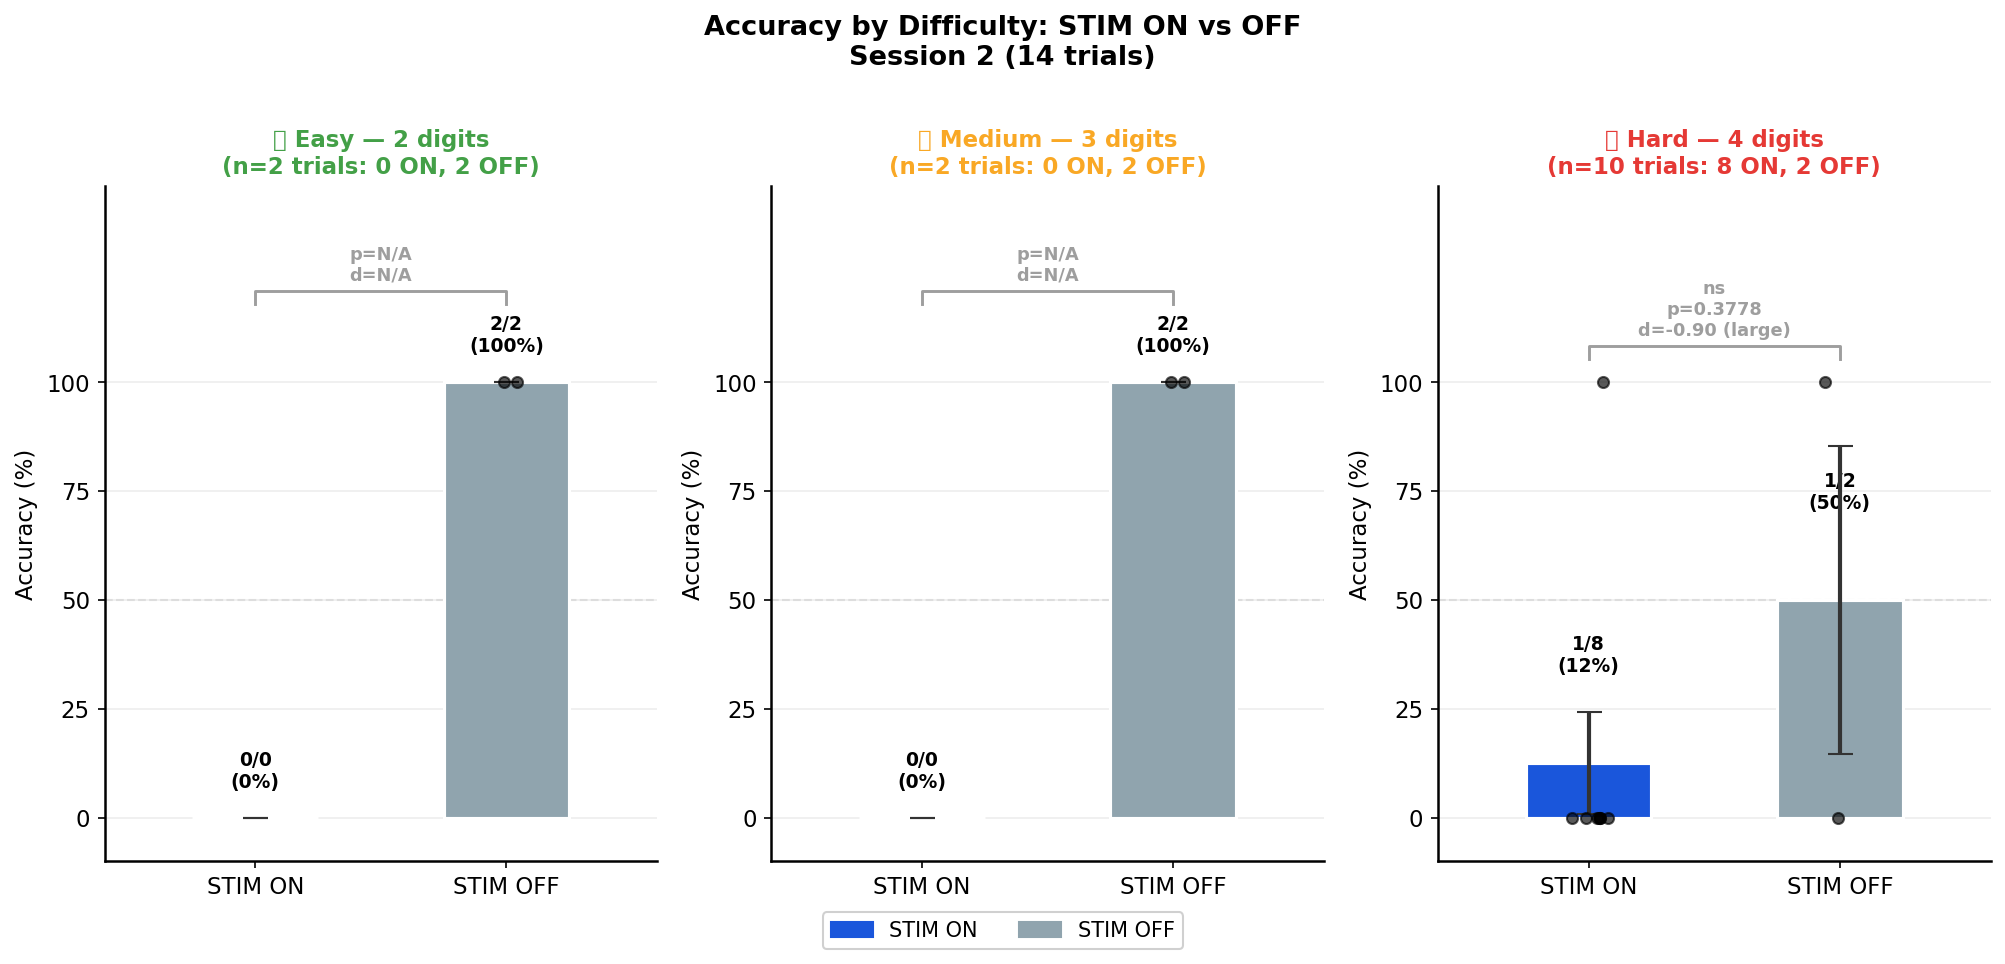

In [20]:
plot_difficulty_stim(
    df_s2,
    sess_label='Session 2 (14 trials)',
    save_path=OUT_DIR_S2 / 'accuracy_by_difficulty_S2.png',
    digit_levels=[d for d in DIGIT_LEVELS if d in df_s2['digits'].unique()]
)

## Cell 10 — Session 3 Plot

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\accuracy_by_difficulty_S3.png


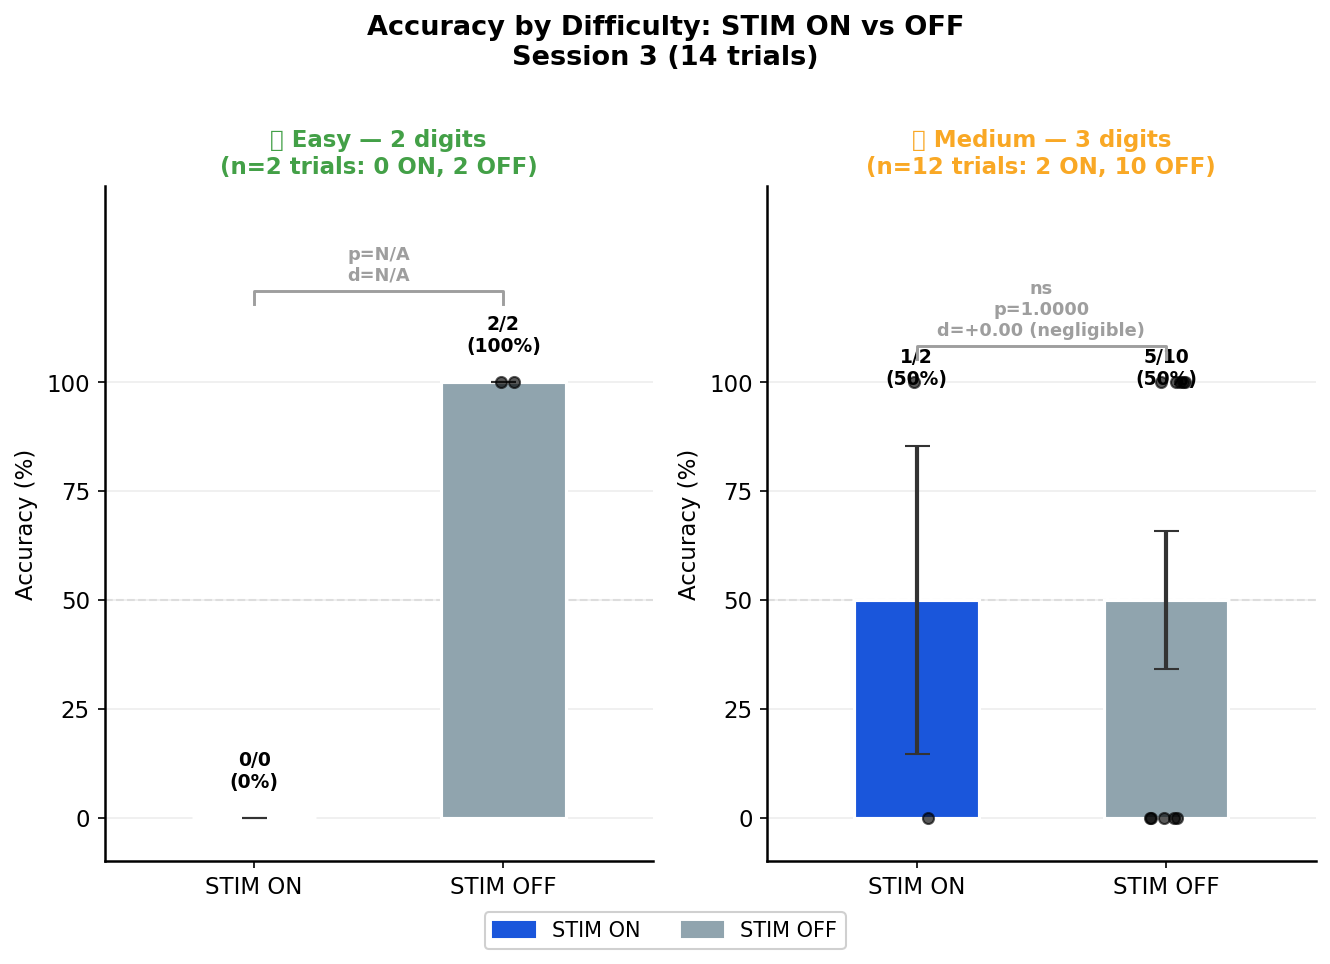

In [21]:
plot_difficulty_stim(
    df_s3,
    sess_label='Session 3 (14 trials)',
    save_path=OUT_DIR_S3 / 'accuracy_by_difficulty_S3.png',
    digit_levels=[d for d in DIGIT_LEVELS if d in df_s3['digits'].unique()]
)

## Cell 11 — Combined (S2 + S3, 28 trials) Plot

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\accuracy_by_difficulty_combined.png


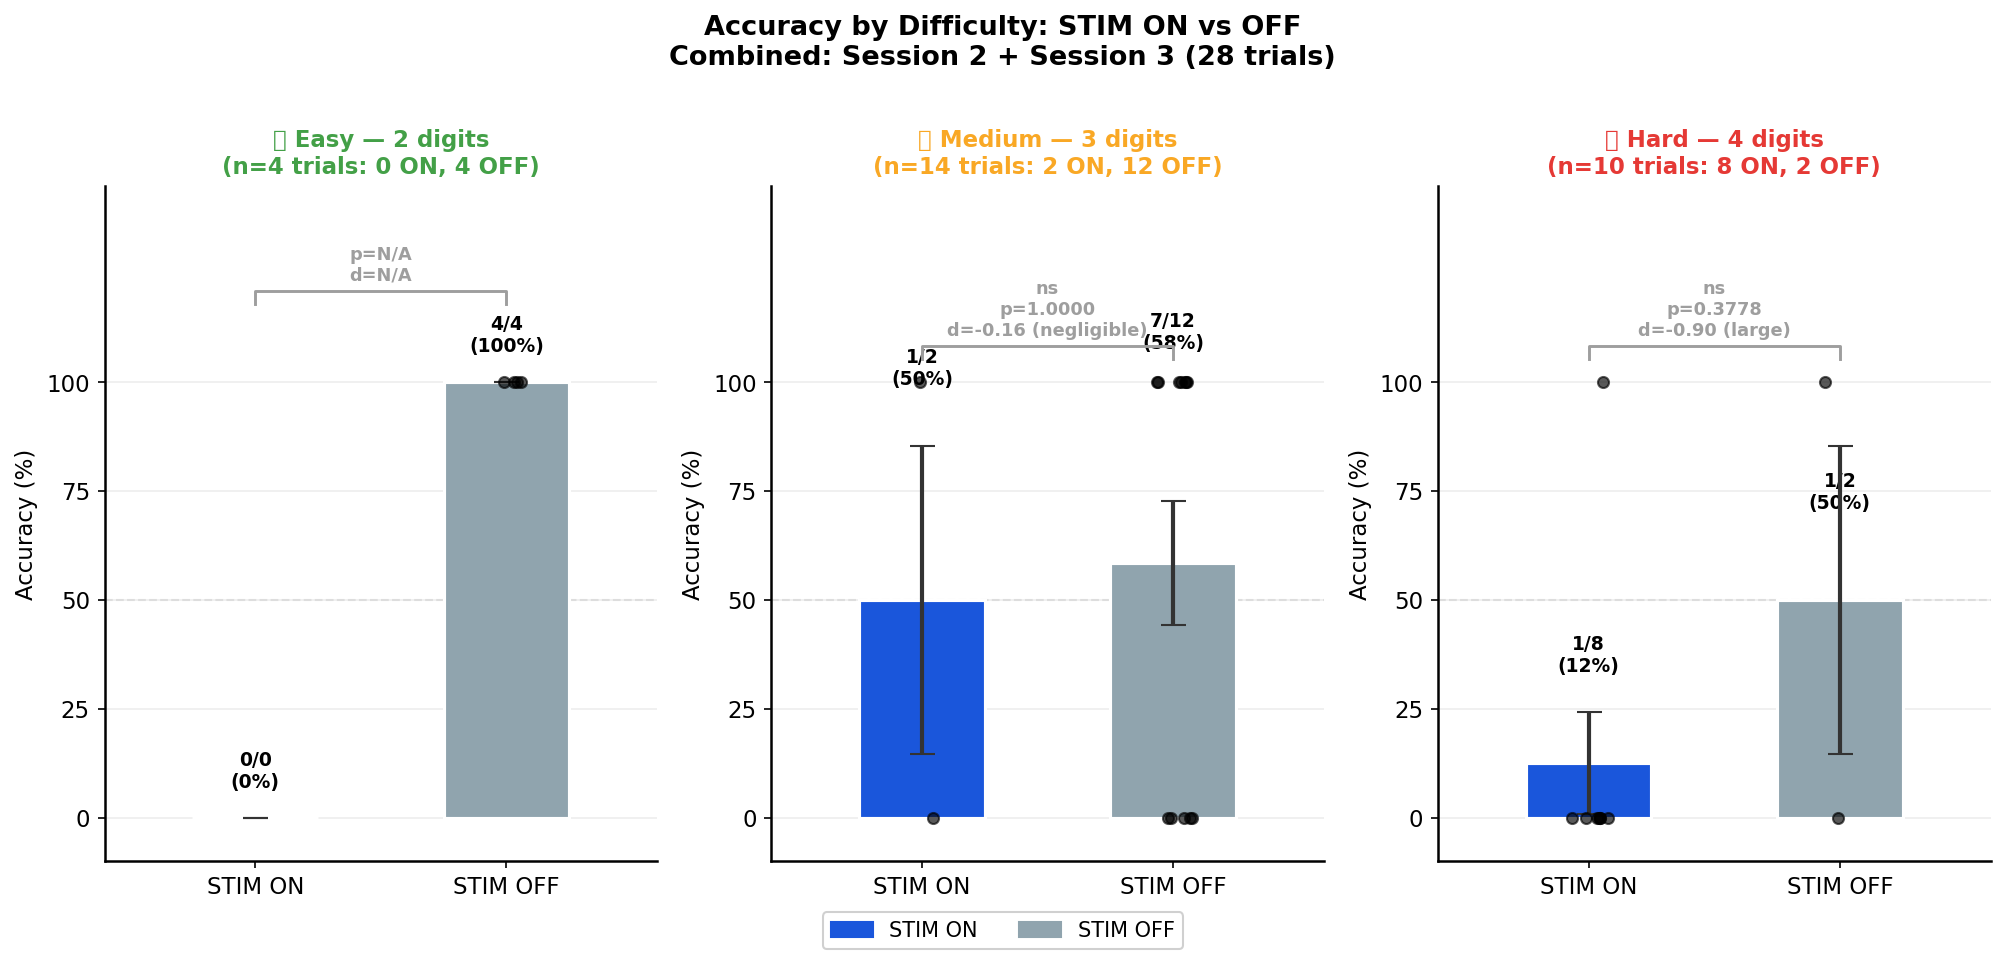

In [22]:
plot_difficulty_stim(
    df_all,
    sess_label='Combined: Session 2 + Session 3 (28 trials)',
    save_path=COMBINED_DIR / 'accuracy_by_difficulty_combined.png',
    digit_levels=[d for d in DIGIT_LEVELS if d in df_all['digits'].unique()]
)

## Cell 12 — Summary Table (DataFrame)
All results in one tidy table.

In [23]:
rows = []
for sess_label, df in [('Session 2', df_s2), ('Session 3', df_s3), ('Combined', df_all)]:
    dig_levels = [d for d in DIGIT_LEVELS if d in df['digits'].unique()]
    for d in dig_levels:
        dm  = DIFF_META.get(d, {})
        sub = df[df['digits'] == d]
        c   = compute_cell(sub)

        rows.append(dict(
            Session      = sess_label,
            Difficulty   = f"{dm.get('emoji','')} {dm.get('label',str(d))}",
            Digits       = d,
            N_ON         = c['n_on'],
            Correct_ON   = c['n_corr_on'],
            Acc_ON       = f"{c['acc_on']*100:.1f}%" if not np.isnan(c['acc_on'])  else '—',
            N_OFF        = c['n_off'],
            Correct_OFF  = c['n_corr_off'],
            Acc_OFF      = f"{c['acc_off']*100:.1f}%" if not np.isnan(c['acc_off']) else '—',
            p_value      = f"{c['p']:.4f}" if not np.isnan(c['p']) else 'N/A',
            Sig          = sig_stars(c['p']),
            Cohens_d     = f"{c['d']:+.3f}" if not np.isnan(c['d']) else 'N/A',
            Effect_Size  = d_label(c['d']),
        ))

summary_df = pd.DataFrame(rows)
display(summary_df)

# Optional: save to CSV
summary_df.to_csv(COMBINED_DIR / 'accuracy_difficulty_stats.csv', index=False)
print(f'\nSaved → {COMBINED_DIR / "accuracy_difficulty_stats.csv"}')

,Session,Difficulty,Digits,N_ON,Correct_ON,Acc_ON,N_OFF,Correct_OFF,Acc_OFF,p_value,Sig,Cohens_d,Effect_Size
0,Session 2,🟢 Easy,2,0,0,—,2,2,100.0%,N/A,,N/A,N/A
1,Session 2,🟡 Medium,3,0,0,—,2,2,100.0%,N/A,,N/A,N/A
2,Session 2,🔴 Hard,4,8,1,12.5%,2,1,50.0%,0.3778,ns,-0.905,large
3,Session 3,🟢 Easy,2,0,0,—,2,2,100.0%,N/A,,N/A,N/A
4,Session 3,🟡 Medium,3,2,1,50.0%,10,5,50.0%,1.0000,ns,+0.000,negligible
5,Combined,🟢 Easy,2,0,0,—,4,4,100.0%,N/A,,N/A,N/A
6,Combined,🟡 Medium,3,2,1,50.0%,12,7,58.3%,1.0000,ns,-0.156,negligible
7,Combined,🔴 Hard,4,8,1,12.5%,2,1,50.0%,0.3778,ns,-0.905,large



Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Combined\accuracy_difficulty_stats.csv
